# TASK 8P
Tyson Mitchell, s225734851

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("/Users/tysonmitchell/Downloads/bank-additional-full.csv", sep=";")
df = df.drop('duration', axis=1) #similar to last task, as recommended by the database 
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [2]:
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

#label encode target variable  
le = preprocessing.LabelEncoder()
df['y'] = le.fit_transform(df['y'].values)

#separating x and y
y = df['y']
X = df.drop('y', axis = 1)

#Now, we will encode all categorical values using get_dummies. information for this part comes 
#from this youtube video https://www.youtube.com/watch?v=jo2ygt81nKY&t=110s
X = pd.get_dummies(X, drop_first = True) #drop first = true will create k-1 dummies and prevent collinearity

#Our data is way too large for SVM, and after trialling with the full training set, 
#SVM takes too long to complete. Therefore, we will sample 20% of the data for the model
X_sample, _, y_sample, _ = train_test_split(X, y, train_size=0.2, random_state=101)

#now, we will split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=101)
print("Train shape: ",X_train.shape)
print("Test shape: ",X_test.shape)

#these steps are identical to task 6p, but we have changed the training testing split to 80/20 instead of 70/30

Train shape:  (6589, 52)
Test shape:  (1648, 52)


In [3]:
print(X_train.info)  

<bound method DataFrame.info of        age  campaign  pdays  previous  emp.var.rate  cons.price.idx  \
2812    35         1    999         0           1.1          93.994   
4833    44         2    999         0           1.1          93.994   
12610   49         3    999         0           1.4          93.918   
30863   37         1    999         1          -1.8          92.893   
16635   21         6    999         0           1.4          93.918   
...    ...       ...    ...       ...           ...             ...   
26937   41         6    999         0          -0.1          93.200   
20141   32         1    999         0           1.4          93.444   
25702   36         1    999         0          -0.1          93.200   
7043    29         2    999         0           1.1          93.994   
26281   46         1    999         0          -0.1          93.200   

       cons.conf.idx  euribor3m  nr.employed  job_blue-collar  ...  month_may  \
2812           -36.4      4.859   

/var/folders/6_/ztnkkj_13dqd8rd5ckb03gfh0000gn/T/ipykernel_23024/2027327597.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=y_train.to_frame(), x='y', palette='Set2')


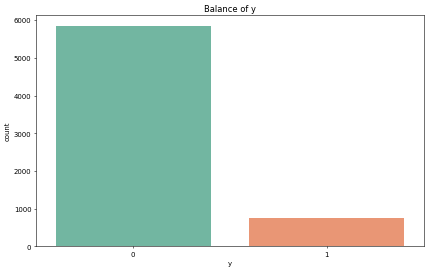

In [4]:
import seaborn as sns

plt.figure(figsize=(10,6),dpi=50)
sns.countplot(data=y_train.to_frame(), x='y', palette='Set2')
plt.title('Balance of y')
plt.show()

In [5]:
#First, let us scale this data 
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

sc.fit(X_train)

X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

In [6]:
# Fit SVM using linear kernel on training data
from sklearn import svm
from sklearn import metrics
import matplotlib.pyplot as plt
svc_model = svm.SVC(kernel='linear')
svc_model.fit(X_train_std, y_train)

#Training/Testing Accuracy:
svc_acc = metrics.accuracy_score(y_train, svc_model.predict(X_train_std))
print("SVM Training Accuracy: {}".format(svc_acc))

#Testing Accuracy:
svc_acc_test = metrics.accuracy_score(y_test, svc_model.predict(X_test_std))
print("SVM Testing Accuracy: {}".format(svc_acc_test))

SVM Training Accuracy: 0.8961906207315222
SVM Testing Accuracy: 0.8932038834951457


As we can see, the testing and training accuracy are both fairly high (~89%). We can also see that both training and testing accuracy are very similar, which indicates that we did not overfit our model. However, it must be noted that as seen previously, our classes are very imbalanced, and therefore the model could have potentially predicted all of our values are 0 with a high accuracy. Therefore, we will also use a classification report. 

In [7]:
from sklearn.metrics import classification_report
print(classification_report(y_test, svc_model.predict(X_test_std)))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1455
           1       0.63      0.21      0.32       193

    accuracy                           0.89      1648
   macro avg       0.77      0.60      0.63      1648
weighted avg       0.87      0.89      0.87      1648



As we can see, our model had a .90 preciison score for no and 0.65 score for yes. This means that our model was right 90% of the time when it predicted 0, but only 63% of the time when it predicted 1. For recall, our model was able to predict 99% of no values, but only 21% of yes values. Our f-1 score indicates that our model was accurate in terms of predicting 'no', but was not highly accurate for predicting 'yes'. 

Now we are going to find the optimal c value. To do this, and to compare the changes in margin for each c value, we are going to use PCA to reduce the dimensions to 2. 

In [8]:
#first we will define a function to allow us to visualise the model
from matplotlib.colors import ListedColormap

# We define a colormap with three colors, for three labels our data
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

def plot_estimator(estimator, X, y):
    '''
    This function takes a model (estimator),
    '''
    print()
    estimator.fit(X, y)
    # Determine the maximum and minimum mesh as a boundary
    x_min, x_max = X[:, 0].min() - .1, X[:, 0].max() + .1
    y_min, y_max = X[:, 1].min() - .1, X[:, 1].max() + .1
    # Generating the points on the mesh
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100))
    # Make predictions on the grid points
    Z = estimator.predict(np.c_[xx.ravel(), yy.ravel()])

    # for color
    Z = Z.reshape(xx.shape)
    plt.figure()
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    # Original training sample
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold)
    plt.axis('tight')
    plt.axis('off')
    plt.tight_layout()

In [9]:
for C in [0.001, 0.01, 0.1, 1, 10]:
    svc = svm.SVC(kernel='linear', C=C)
    svc.fit(X_train_std, y_train)
    f1 = metrics.f1_score(y_test, svc.predict(X_test_std))
    print(f"C={C}: F1={f1:.5f}")

C=0.001: F1=0.31783
C=0.01: F1=0.31783
C=0.1: F1=0.31783
C=1: F1=0.31783
C=10: F1=0.31783


As we can see, all of our c values give identical f1 scores. Therefore,  Now we are going to visualise how the c values change the margin.  

In [10]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
reduced_X_train=pca.fit_transform(X_train_std)
reduced_X_test=pca.transform(X_test_std)
print(reduced_X_test.shape)

(1648, 2)


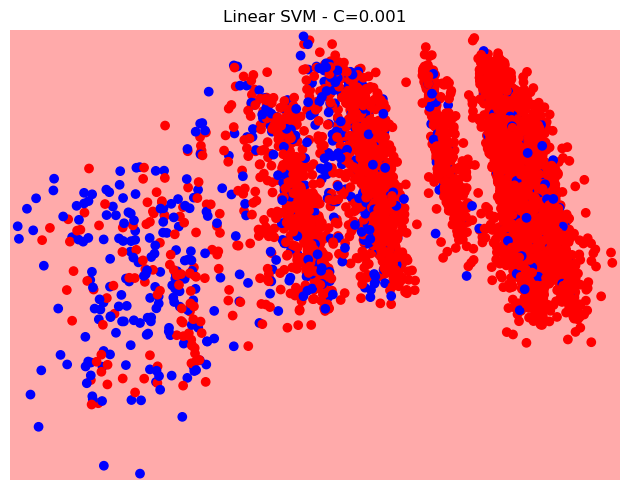

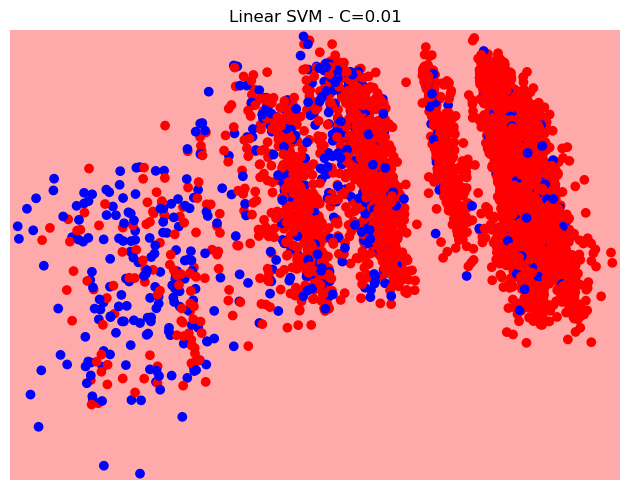

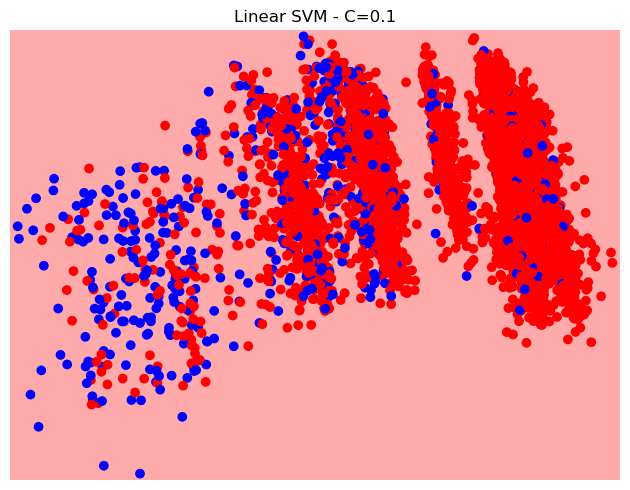

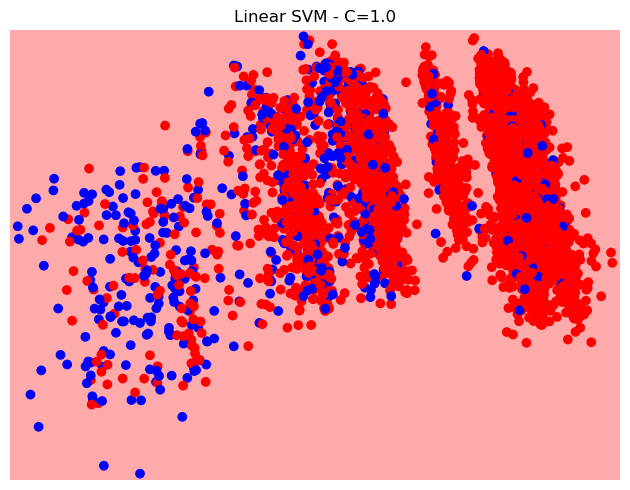

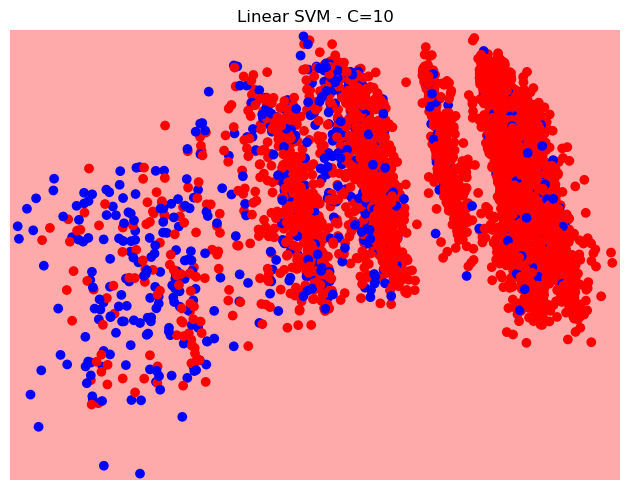

In [11]:
for C in [0.001, 0.01, 0.1, 1.0, 10]:
    svc_plot = svm.SVC(kernel='linear', C=C)
    plot_estimator(svc_plot, reduced_X_train, y_train)
    plt.title(f'Linear SVM - C={C}')
    plt.show()

As we can see, the plots for all of the c values are identical. The models are all predciting majority of values as 'no', and therefore the beackground is entirely red. This problem may be addressed later in the report where we address class imbalance. Now we will try 2 other kernel functions: RBF and poly. We will also find the optimal hypermarater setting. 

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid_rbf = {
    'C': [0.1, 1, 10, 10, 100, 1000],
    'gamma': [0.001, 0.01, 0.1, 1]
}

grid_rbf = GridSearchCV(
    svm.SVC(kernel='rbf'),
    param_grid_rbf,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_rbf.fit(X_train_std, y_train)
print("Best RBF params:", grid_rbf.best_params_)
print("Best RBF F1:", grid_rbf.best_score_)
print(metrics.classification_report(y_test, grid_rbf.predict(X_test_std)))

Best RBF params: {'C': 100, 'gamma': 0.01}
Best RBF F1: 0.33550020654887813
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      1455
           1       0.43      0.30      0.35       193

    accuracy                           0.87      1648
   macro avg       0.67      0.62      0.64      1648
weighted avg       0.85      0.87      0.86      1648



Text(0.5, 1.0, 'RBF kernel')

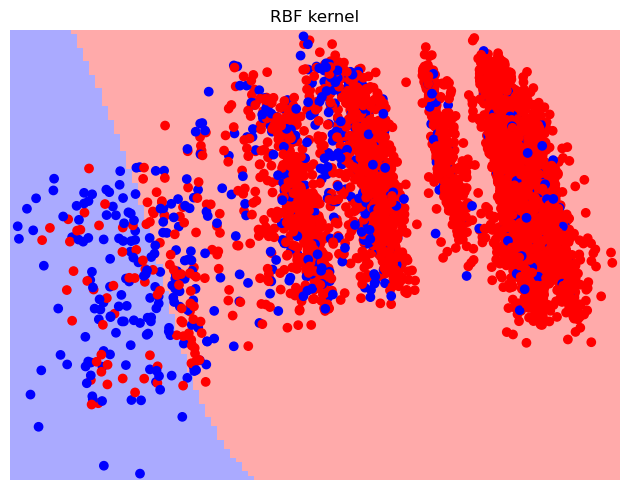

In [13]:
svc_rbf_model = svm.SVC(kernel = 'rbf', C = 100, gamma = 0.01)
svc_rbf_model.fit(X_train_std, y_train)
plot_estimator(svc_rbf_model, reduced_X_train, y_train)
plt.title('RBF kernel')

In [14]:
param_grid_poly = {
    'C': [0.1, 1, 10, 100, 1000],
    'degree': [2, 3, 4, 5, 6]
}

grid_poly = GridSearchCV(
    svm.SVC(kernel='poly'),
    param_grid_poly,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_poly.fit(X_train_std, y_train)
print("Best Poly params:", grid_poly.best_params_)
print("Best Poly F1:", grid_poly.best_score_)
print(metrics.classification_report(y_test, grid_poly.predict(X_test_std)))

Best Poly params: {'C': 10, 'degree': 2}
Best Poly F1: 0.33478826524653726
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1455
           1       0.53      0.26      0.35       193

    accuracy                           0.89      1648
   macro avg       0.72      0.62      0.65      1648
weighted avg       0.86      0.89      0.87      1648



Text(0.5, 1.0, 'Polynomial kernel')

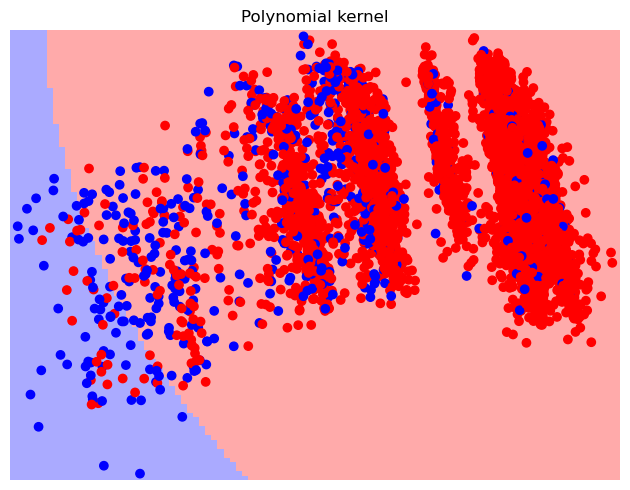

In [15]:
svc_poly_model = svm.SVC(kernel = 'poly', C = 10, degree = 2)
svc_poly_model.fit(X_train_std, y_train)
plot_estimator(svc_poly_model, reduced_X_train, y_train)
plt.title('Polynomial kernel')

As we can see, the best c value for rbf kernel functions is 100, while for the poly kernel function it is 10. For RBF kernel, the best gamma value is 0.01. For poly kernel, the best degree is 2. Both tests give an f1 score of 0.35 for the test set, which is higher than the f1 score for our linear model (0.32). We will print the unrounded f1 scores of each to find the best hyperparamater setting. 

In [16]:
print("RBF F1:", metrics.f1_score(y_test, grid_rbf.predict(X_test_std)))
print("Poly Test F1:", metrics.f1_score(y_test, grid_poly.predict(X_test_std)))

RBF F1: 0.3486238532110092
Poly Test F1: 0.35294117647058826


As we can see, the poly test F1 is slightly higher than the RBF test f1 (0.3529 > 0.3486). Therefore, the poly kernel function with C = 10 and degree = 2 is our best hyperparameter setting. Now, we will use this to find how many support vectors there are for the SVM model. 

In [17]:
svc_poly_model.fit(X_train_std, y_train) 

print("Data has a total of {} support vectors".format(svc_poly_model.support_vectors_.shape[0]))

print("Training accuracy: {}".format(metrics.accuracy_score(y_train, svc_poly_model.predict(X_train_std))))
print("Testing accuracy : {}".format(metrics.accuracy_score(y_test, svc_poly_model.predict(X_test_std))))

Data has a total of 1606 support vectors
Training accuracy: 0.925330095613902
Testing accuracy : 0.8865291262135923


The support vectors are the data points within the bodel that lie the closest to the decision boundary. These data points define where the boundary is, and a small number of support vectors indicates that the boundary is very well defined. Ideally, we would want a large distance between data points and the boundary line to minimise conflict between classification, and thus we want a small number of support vectors. However, a large number of support vectors indicates the boundary line is not very clear and defined, as is the case in our model. As we can see in our poly plot from earlier, there is a lot of overlap between data points in our classes. This could be caused by class imbalance, which we will now address. 

In [18]:
svc_balanced = svm.SVC(kernel='poly', C=10, degree = 2, class_weight='balanced')
svc_balanced.fit(X_train_std, y_train)
svc_rbf_model.fit(X_train_std, y_train) #currently fitted to pca data from plotting cell

print("Balanced Model Classification Report:")
print(metrics.classification_report(y_test, svc_balanced.predict(X_test_std)))

# Comparing F1 scores
print("Original F1:", metrics.f1_score(y_test, svc_poly_model.predict(X_test_std)))
print("Balanced F1:", metrics.f1_score(y_test, svc_balanced.predict(X_test_std)))

Balanced Model Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.81      0.86      1455
           1       0.27      0.54      0.36       193

    accuracy                           0.78      1648
   macro avg       0.60      0.68      0.61      1648
weighted avg       0.85      0.78      0.81      1648

Original F1: 0.35294117647058826
Balanced F1: 0.3626943005181347


We have used the built in class_weight = 'balanced' command in the SVC library. The reason we have used this compared to random over/under sampling due to simplicity, as we do not have to install a new package or perform large amounts of code, and it does not generate synthetic data/loss of training data. Class imbalance will punish missing a 'yes' value more heavily compared to missing a 'no' value, and thus makes the misclassifying punishment proportional to class frequency. This will address class imbalance by resulting in an equal weight given to each class. As we can see in our results, the balanced f1 score was higher than the original f1 score, indicating that our balanced model was better fitting for 'yes' values. With that said, the f1 score for 'yes' values was 0.94 in our original poly model. This indicates that the original poly model was a better fit for predicting 'no' values. 